## Output Directory Declaration

In [1]:
import os, glob, json, time, random
import numpy as np
import torch

os.makedirs("./data/hippocampus", exist_ok=True)
os.makedirs("./model_pth_hippo", exist_ok=True)
os.makedirs("./results_hippo", exist_ok=True)
os.makedirs("./overlays_hippo", exist_ok=True)
os.makedirs("./logs_hippo", exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


## Download the MSD Data

In [2]:
if not os.path.exists("Task04_Hippocampus.tar"):
    os.system("wget -q https://msd-for-monai.s3-us-west-2.amazonaws.com/Task04_Hippocampus.tar")
    print("downloaded")
else:
    print("tar already present, skipping download")

if not os.path.exists("Task04_Hippocampus"):
    os.system("tar -xf Task04_Hippocampus.tar")
    print("extracted")
else:
    print("already extracted, skipping")

img_paths_all = sorted(glob.glob("Task04_Hippocampus/imagesTr/*.nii.gz"))
lbl_paths_all = sorted(glob.glob("Task04_Hippocampus/labelsTr/*.nii.gz"))
print("Total labeled 3D volumes:", len(img_paths_all))

downloaded
extracted
Total labeled 3D volumes: 260


## CHECKING THE AXIS and Slice Number

In [3]:
import nibabel as nib

sample_img = nib.load(img_paths_all[0])
affine = sample_img.affine
axcodes = nib.aff2axcodes(affine)
print("Axis codes:", axcodes)
print("Shape:", sample_img.shape)

Axis codes: ('R', 'A', 'S')
Shape: (35, 51, 35)


## Make 3D to 2D Slices for Axial Plane

In [5]:
out_base = "./data/hippocampus"
split_marker = f"{out_base}/.extraction_done"


AXIAL_AXIS = 0 

if os.path.exists(split_marker):
    print("Slice extraction already completed previously, skipping.")
else:
    rng = np.random.RandomState(42) 
    idx = rng.permutation(len(img_paths_all))
    n_train = int(0.8 * len(idx))
    n_val = int(0.1 * len(idx))
    splits = {
        'train': idx[:n_train],
        'val':   idx[n_train:n_train + n_val],
        'test':  idx[n_train + n_val:]
    }

    for split in splits:
        os.makedirs(f"{out_base}/{split}/images", exist_ok=True)
        os.makedirs(f"{out_base}/{split}/masks", exist_ok=True)

    for split, indices in splits.items():
        for i in indices:
            img_vol = nib.load(img_paths_all[i]).get_fdata().astype(np.float32)
            lbl_vol = nib.load(lbl_paths_all[i]).get_fdata().astype(np.uint8)
            case_name = os.path.basename(img_paths_all[i]).replace('.nii.gz', '')

            num_slices = img_vol.shape[AXIAL_AXIS]

            for s in range(num_slices):
                
                img_slice = np.take(img_vol, indices=s, axis=AXIAL_AXIS)
                lbl_slice = np.take(lbl_vol, indices=s, axis=AXIAL_AXIS)

                if img_slice.max() > img_slice.min():
                    img_slice = (img_slice - img_slice.min()) / (img_slice.max() - img_slice.min())

                np.save(f"{out_base}/{split}/images/{case_name}_s{s:03d}.npy", img_slice.astype(np.float32))
                np.save(f"{out_base}/{split}/masks/{case_name}_s{s:03d}.npy", lbl_slice.astype(np.uint8))
        print(f"{split}: {len(indices)} volumes done")

    with open(split_marker, "w") as f:
        f.write("done")
    print("Slice extraction complete.")

for split in ['train', 'val', 'test']:
    n = len(os.listdir(f"{out_base}/{split}/images")) if os.path.exists(f"{out_base}/{split}/images") else 0
    print(split, "2D slices:", n)

train: 208 volumes done
val: 26 volumes done
test: 26 volumes done
Slice extraction complete.
train 2D slices: 7377
val 2D slices: 906
test 2D slices: 915


## Make 3D to 2D Slices for Coronal Plane

In [6]:
out_base_coronal = "./data/hippocampus_coronal"  
split_marker_coronal = f"{out_base_coronal}/.extraction_done"

CORONAL_AXIS = 1

if os.path.exists(split_marker_coronal):
    print("Coronal slice extraction already done, skipping.")
else:
    rng = np.random.RandomState(42) 
    idx = rng.permutation(len(img_paths_all))
    n_train = int(0.8 * len(idx))
    n_val = int(0.1 * len(idx))
    splits = {'train': idx[:n_train], 'val': idx[n_train:n_train+n_val], 'test': idx[n_train+n_val:]}

    for split in splits:
        os.makedirs(f"{out_base_coronal}/{split}/images", exist_ok=True)
        os.makedirs(f"{out_base_coronal}/{split}/masks", exist_ok=True)

    for split, indices in splits.items():
        for i in indices:
            img_vol = nib.load(img_paths_all[i]).get_fdata().astype(np.float32)
            lbl_vol = nib.load(lbl_paths_all[i]).get_fdata().astype(np.uint8)
            case_name = os.path.basename(img_paths_all[i]).replace('.nii.gz', '')

            n_slices_this_axis = img_vol.shape[CORONAL_AXIS]
            for s in range(n_slices_this_axis):
                img_slice = np.take(img_vol, s, axis=CORONAL_AXIS)
                lbl_slice = np.take(lbl_vol, s, axis=CORONAL_AXIS)

                if img_slice.max() > img_slice.min():
                    img_slice = (img_slice - img_slice.min()) / (img_slice.max() - img_slice.min())

                np.save(f"{out_base_coronal}/{split}/images/{case_name}_s{s:03d}.npy", img_slice.astype(np.float32))
                np.save(f"{out_base_coronal}/{split}/masks/{case_name}_s{s:03d}.npy", lbl_slice.astype(np.uint8))
        print(f"{split}: {len(indices)} volumes done (coronal)")

    with open(split_marker_coronal, "w") as f:
        f.write("done")
    print("Slice extraction complete.")

for split in ['train', 'val', 'test']:
    n = len(os.listdir(f"{out_base_coronal}/{split}/images"))
    print(split, "2D slices:", n)

train: 208 volumes done (coronal)
val: 26 volumes done (coronal)
test: 26 volumes done (coronal)
Slice extraction complete.
train 2D slices: 10366
val 2D slices: 1295
test 2D slices: 1334


In [10]:
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

class HippocampusDataset(Dataset):
    def __init__(self, split_dir, img_size=64):
        self.img_paths = sorted(glob.glob(f"{split_dir}/images/*.npy"))
        self.mask_paths = sorted(glob.glob(f"{split_dir}/masks/*.npy"))
        assert len(self.img_paths) == len(self.mask_paths)
        self.img_size = img_size

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = np.load(self.img_paths[idx]).astype(np.float32)
        mask = np.load(self.mask_paths[idx]).astype(np.int64)

        img_t = torch.from_numpy(img).unsqueeze(0).unsqueeze(0)     
        mask_t = torch.from_numpy(mask).unsqueeze(0).unsqueeze(0).float()  

        img_t = F.interpolate(img_t, size=(self.img_size, self.img_size), mode='bilinear', align_corners=False)
        mask_t = F.interpolate(mask_t, size=(self.img_size, self.img_size), mode='nearest')

        img_t = img_t.squeeze(0)        
        mask_t = mask_t.squeeze(0).squeeze(0).long() 


        img_t = img_t.repeat(3, 1, 1)

        return img_t, mask_t, os.path.basename(self.img_paths[idx])

# For Axial Plane
#train_ds = HippocampusDataset(f"{out_base}/train")
#val_ds   = HippocampusDataset(f"{out_base}/val")
#test_ds  = HippocampusDataset(f"{out_base}/test")

#print("train/val/test slice counts:", len(train_ds), len(val_ds), len(test_ds))


# For Coronal Plane
train_ds_coronal = HippocampusDataset(f"{out_base_coronal}/train")
val_ds_coronal   = HippocampusDataset(f"{out_base_coronal}/val")
test_ds_coronal  = HippocampusDataset(f"{out_base_coronal}/test")
print(len(train_ds_coronal), len(val_ds_coronal), len(test_ds_coronal))



10366 1295 1334


## CHECKING 3D SAMPLE

In [5]:
import nibabel as nib
import numpy as np
import plotly.graph_objects as go
from skimage import measure

lbl = nib.load(lbl_paths_all[20]).get_fdata()

fig = go.Figure()
colors = {1: 'green', 2: 'orange'}
names = {1: 'Anterior', 2: 'Posterior'}

for class_id in [1, 2]:
    binary_mask = (lbl == class_id).astype(np.uint8)
    if binary_mask.sum() == 0:
        continue  # skip if this volume has no voxels of this class
    verts, faces, _, _ = measure.marching_cubes(binary_mask, level=0.5)
    fig.add_trace(go.Mesh3d(
        x=verts[:, 0], y=verts[:, 1], z=verts[:, 2],
        i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
        color=colors[class_id], opacity=0.8, name=names[class_id]
    ))

fig.update_layout(title="3D shape of hippocampus (ground truth)", width=700, height=700,
                   scene=dict(aspectmode='data'))
fig.show()


## 2D Slices

Volume shape (H, W, D): (36, 47, 41)


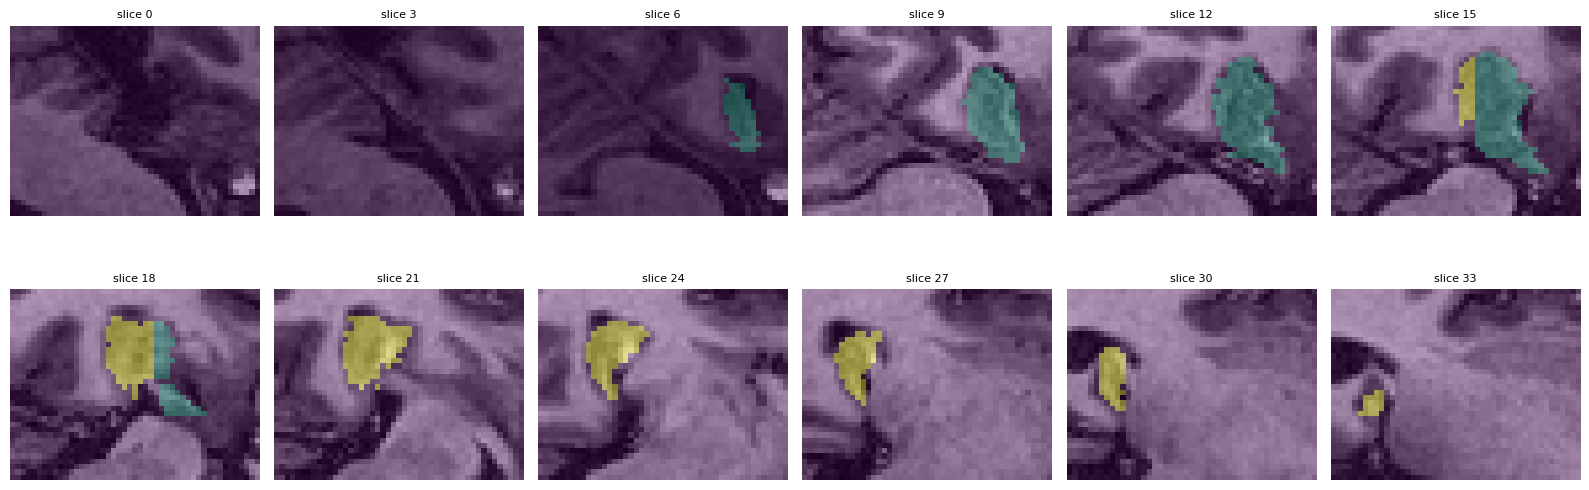

In [22]:
import nibabel as nib
import matplotlib.pyplot as plt

vol_path = img_paths_all[10]  
lbl_path = lbl_paths_all[10]

vol = nib.load(vol_path).get_fdata()
lbl = nib.load(lbl_path).get_fdata()

print("Volume shape (H, W, D):", vol.shape)

n_slices = vol.shape[2]
step = max(1, n_slices // 12)   

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for i, s in enumerate(range(0, n_slices, step)):
    if i >= 12: break
    row, col = i // 6, i % 6
    axes[row, col].imshow(vol[:, :, s], cmap='gray')
    axes[row, col].imshow(lbl[:, :, s], cmap='viridis', alpha=0.4, vmin=0, vmax=2)  
    axes[row, col].set_title(f"slice {s}", fontsize=8)
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('./volume_overview.png', dpi=100)
plt.show()

## Import MK-UNet Model from Kaggle/Input

In [7]:
import os, importlib.util, torch

file_path = "/kaggle/input/datasets/mahadihasanshaisob/mk-unet-github-repo/MK-UNet/mkunet_network.py"
assert os.path.exists(file_path), f"file not found at {file_path}"

spec = importlib.util.spec_from_file_location("mkunet_network", file_path)
mkunet_network = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mkunet_network)

MK_UNet = mkunet_network.MK_UNet
print("Imported MK_UNet successfully")

Imported MK_UNet successfully


/usr/local/lib/python3.13/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.13/dist-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


## Declaration of MK-UNet Configs

In [9]:
NET_CONFIGS = {
    'MK_UNet_T': [4, 8, 16, 24, 32],
    'MK_UNet_S': [8, 16, 32, 48, 80],
    'MK_UNet':   [16, 32, 64, 96, 160],
    'MK_UNet_M': [32, 64, 128, 192, 320],
    'MK_UNet_L': [64, 128, 256, 384, 512]
}

NUM_CLASSES = 3
network_name = 'MK_UNet_L'
channels = NET_CONFIGS[network_name]

model = MK_UNet(num_classes=NUM_CLASSES, in_channels=3, channels=channels).to(DEVICE)

dummy = torch.randn(1, 3, 64, 64).to(DEVICE)
with torch.no_grad():
    out = model(dummy)
    out = out[0] if isinstance(out, list) else out
print(out.shape)

torch.Size([1, 3, 64, 64])


## Loss Function

In [10]:
import torch.nn as nn

def multiclass_dice_loss(pred_logits, target, num_classes=3, smooth=1e-6):
    """pred_logits: [B,C,H,W] raw logits. target: [B,H,W] int class map."""
    pred_probs = torch.softmax(pred_logits, dim=1)                  
    target_onehot = F.one_hot(target, num_classes=num_classes).permute(0, 3, 1, 2).float()

    dims = (0, 2, 3)
    intersection = (pred_probs * target_onehot).sum(dims)
    union = pred_probs.sum(dims) + target_onehot.sum(dims)
    dice_per_class = (2. * intersection + smooth) / (union + smooth)
    return 1 - dice_per_class.mean()

ce_loss_fn = nn.CrossEntropyLoss()

def combined_loss(pred_logits, target, num_classes=3):
    ce = ce_loss_fn(pred_logits, target)
    dice = multiclass_dice_loss(pred_logits, target, num_classes=num_classes)
    return ce + dice

def per_class_dice(pred_logits, target, num_classes=3, smooth=1e-6):
    """Returns a list of Dice scores, one per class, for reporting (Point 4)."""
    pred_classes = torch.argmax(pred_logits, dim=1)
    dices = []
    for c in range(num_classes):
        pred_c = (pred_classes == c).float()
        target_c = (target == c).float()
        intersection = (pred_c * target_c).sum()
        union = pred_c.sum() + target_c.sum()
        dices.append(((2. * intersection + smooth) / (union + smooth)).item())
    return dices  

## Training

In [15]:
# For Axial Plane

#RUN_ID = f"Hippocampus_{network_name}_bs8_lr0.0005_e100"
#ckpt_path = f"./model_pth_hippo/{RUN_ID}_resume.pth"
#log_path = f"./logs_hippo/{RUN_ID}_log.txt"


# For Coronal Plane
RUN_ID = f"Hippocampus_{network_name}_coronal_bs8_lr0.0005_e100"  
ckpt_path = f"./model_pth_hippo/{RUN_ID}_resume.pth"
log_path = f"./logs_hippo/{RUN_ID}_log.txt"



BATCH_SIZE = 8
LR = 0.0005
TOTAL_EPOCHS = 100


model = MK_UNet(num_classes=NUM_CLASSES, in_channels=3, channels=channels).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

start_epoch = 0
best_val_dice = 0.0

if os.path.exists(ckpt_path):
    checkpoint = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state'])
    optimizer.load_state_dict(checkpoint['optimizer_state'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_dice = checkpoint['best_val_dice']
    print(f"Resumed from epoch {start_epoch} (best val Dice so far: {best_val_dice:.4f})")
else:
    print("No checkpoint found, starting fresh from epoch 0")

# For Axial Plane

#train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
#val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# For Coronal Plane

train_loader = DataLoader(train_ds_coronal, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds_coronal, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


log_file = open(log_path, "a")  

for epoch in range(start_epoch, TOTAL_EPOCHS):
    model.train()
    train_loss_sum = 0.0
    for imgs, masks, _ in train_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        preds = model(imgs)
        preds = preds[0] if isinstance(preds, list) else preds
        loss = combined_loss(preds, masks, num_classes=NUM_CLASSES)
        loss.backward()
        optimizer.step()
        train_loss_sum += loss.item()
    avg_train_loss = train_loss_sum / len(train_loader)

    model.eval()
    val_dices = []
    with torch.no_grad():
        for imgs, masks, _ in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            preds = model(imgs)
            preds = preds[0] if isinstance(preds, list) else preds
            d = per_class_dice(preds, masks, num_classes=NUM_CLASSES)
            val_dices.append(d)
    val_dices = np.array(val_dices).mean(axis=0)  
    val_mean_dice = val_dices[1:].mean()           

    log_line = (
    f"Epoch {epoch+1}/{TOTAL_EPOCHS} | "
    f"train_loss={avg_train_loss:.4f} | "
    f"val_dice_background={val_dices[0]:.4f} | "
    f"val_dice_anterior={val_dices[1]:.4f} | "
    f"val_dice_posterior={val_dices[2]:.4f} | "
    f"val_mean_dice_all={val_dices.mean():.4f} | "
    f"val_mean_dice_fg={val_mean_dice:.4f}"
)
    print(log_line)
    log_file.write(log_line + "\n")
    log_file.flush()   

    is_best = val_mean_dice > best_val_dice
    if is_best:
        best_val_dice = val_mean_dice
        torch.save(model.state_dict(), f"./model_pth_hippo/{RUN_ID}-best.pth")

    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'best_val_dice': best_val_dice,
    }, ckpt_path)

log_file.close()
print("Training finished (or reached TOTAL_EPOCHS). Best val Dice:", best_val_dice)

No checkpoint found, starting fresh from epoch 0
Epoch 1/100 | train_loss=0.2522 | val_dice_background=0.9924 | val_dice_anterior=0.8647 | val_dice_posterior=0.8596 | val_mean_dice_all=0.9056 | val_mean_dice_fg=0.8621
Epoch 2/100 | train_loss=0.1817 | val_dice_background=0.9924 | val_dice_anterior=0.8208 | val_dice_posterior=0.8469 | val_mean_dice_all=0.8867 | val_mean_dice_fg=0.8338
Epoch 3/100 | train_loss=0.1665 | val_dice_background=0.9927 | val_dice_anterior=0.8640 | val_dice_posterior=0.8384 | val_mean_dice_all=0.8983 | val_mean_dice_fg=0.8512
Epoch 4/100 | train_loss=0.1625 | val_dice_background=0.9926 | val_dice_anterior=0.8495 | val_dice_posterior=0.8316 | val_mean_dice_all=0.8912 | val_mean_dice_fg=0.8405
Epoch 5/100 | train_loss=0.1594 | val_dice_background=0.9929 | val_dice_anterior=0.8620 | val_dice_posterior=0.8567 | val_mean_dice_all=0.9038 | val_mean_dice_fg=0.8593
Epoch 6/100 | train_loss=0.1560 | val_dice_background=0.9930 | val_dice_anterior=0.8602 | val_dice_posteri

## Testing and Results

In [16]:
import pandas as pd
import matplotlib.pyplot as plt


# For Axial Plane

#model.load_state_dict(torch.load(f"./model_pth_hippo/{RUN_ID}-best.pth"))
#model.eval()
#test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=2)


# For Coronal Plane

model.load_state_dict(torch.load(f"./model_pth_hippo/{RUN_ID}-best.pth"))
model.eval()
test_loader = DataLoader(test_ds_coronal, batch_size=1, shuffle=False, num_workers=2)



all_dices = []
overlay_count = 0
MAX_OVERLAYS = 20 

with torch.no_grad():
    for imgs, masks, names in test_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        preds = model(imgs)
        preds = preds[0] if isinstance(preds, list) else preds
        d = per_class_dice(preds, masks, num_classes=NUM_CLASSES)
        all_dices.append({'Name': names[0], 'Dice_Background': d[0], 'Dice_Anterior': d[1], 'Dice_Posterior': d[2]})

        pred_mask = torch.argmax(preds, dim=1)[0].cpu().numpy()
        gt_mask = masks[0].cpu().numpy()
        if overlay_count < MAX_OVERLAYS and gt_mask.max() > 0:
            fig, axes = plt.subplots(1, 3, figsize=(9, 3))
            axes[0].imshow(imgs[0, 0].cpu().numpy(), cmap='gray')
            axes[0].set_title("MRI slice")
            axes[1].imshow(gt_mask, cmap='viridis', vmin=0, vmax=2)
            axes[1].set_title("Ground truth")
            axes[2].imshow(pred_mask, cmap='viridis', vmin=0, vmax=2)
            axes[2].set_title("Prediction")
            for ax in axes: ax.axis('off')
            plt.tight_layout()
            plt.savefig(f"./overlays_hippo/{names[0].replace('.npy','')}.png", dpi=100)
            plt.close()
            overlay_count += 1

df = pd.DataFrame(all_dices)
mean_row = df.mean(numeric_only=True).to_dict()
mean_row['Name'] = 'AVERAGE'
df = pd.concat([df, pd.DataFrame([mean_row])], ignore_index=True)
df.to_excel(f"./results_hippo/Results_{RUN_ID}_test.xlsx", index=False)

print(f"\nFINAL RESULTS: {RUN_ID}")
print(f"Mean Dice (Anterior + Posterior, excluding background): {(mean_row['Dice_Anterior']+mean_row['Dice_Posterior'])/2:.4f}")
print(f"Class-wise Dice — Anterior: {mean_row['Dice_Anterior']:.4f} | Posterior: {mean_row['Dice_Posterior']:.4f}")
print(f"Excel saved to: results_hippo/Results_{RUN_ID}_test.xlsx")
print(f"Dice — Background: {mean_row['Dice_Background']:.4f} | Anterior: {mean_row['Dice_Anterior']:.4f} | Posterior: {mean_row['Dice_Posterior']:.4f}")
print(f"{overlay_count} overlay images saved to: ./overlays_hippo/")

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.

FINAL RESULTS: Hippocampus_MK_UNet_L_coronal_bs8_lr0.0005_e100
Mean Dice (Anterior + Posterior, excluding background): 0.9188
Class-wise Dice — Anterior: 0.9254 | Posterior: 0.9122
Excel saved to: results_hippo/Results_Hippocampus_MK_UNet_L_coronal_bs8_lr0.0005_e100_test.xlsx
Dice — Background: 0.9932 | Anterior: 0.9254 | Posterior: 0.9122
20 overlay images saved to: ./overlays_hippo/


## Make ZIP File for results

In [41]:
import shutil, os

zip_name = "Hippocampus_Results"

folders_to_include = [
    "./model_pth_hippo",
    "./results_hippo",    
    "./overlays_hippo",    
    "./logs_hippo",       
]

staging_dir = f"./{zip_name}"
os.makedirs(staging_dir, exist_ok=True)

for folder in folders_to_include:
    if os.path.exists(folder):
        dest = os.path.join(staging_dir, os.path.basename(folder))
        shutil.copytree(folder, dest, dirs_exist_ok=True)
    else:
        print(f"WARNING: {folder} not found, skipping")

for extra_file in ["sample_slices_check.png", "volume_overview.png"]:
    if os.path.exists(extra_file):
        shutil.copy(extra_file, staging_dir)
        print(f"copied {extra_file}")

shutil.make_archive(zip_name, 'zip', staging_dir)
print(f"\nZip created: {zip_name}.zip ({os.path.getsize(zip_name)


copied ./model_pth_hippo -> ./Hippocampus_Deliverable_Package/model_pth_hippo
copied ./results_hippo -> ./Hippocampus_Deliverable_Package/results_hippo
copied ./overlays_hippo -> ./Hippocampus_Deliverable_Package/overlays_hippo
copied ./logs_hippo -> ./Hippocampus_Deliverable_Package/logs_hippo
copied sample_slices_check.png
copied volume_overview.png

Zip created: Hippocampus_Deliverable_Package.zip (5.22 MB)
Download it from the Kaggle 'Output' panel on the right side of the notebook.
